In [1]:
import json
import pandas as pd
# Load Json
with open("CUAD_v1.json") as f:
    data=json.load(f)
    
#convert to dataframe
rows=[]
for item in data["data"]:
    for para in item["paragraphs"]:
        for qa in para["qas"]:
            rows.append({
                "contract":item["title"],
                "clause_type":qa["question"],
                   "answer": qa["answers"][0]["text"] if qa["answers"] else None,
                "context": para["context"]
            })    
            
            
df = pd.DataFrame(rows)
print(df.shape)
print(df.head())            

(20910, 4)
                                            contract  \
0  LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...   
1  LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...   
2  LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...   
3  LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...   
4  LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...   

                                         clause_type  \
0  Highlight the parts (if any) of this contract ...   
1  Highlight the parts (if any) of this contract ...   
2  Highlight the parts (if any) of this contract ...   
3  Highlight the parts (if any) of this contract ...   
4  Highlight the parts (if any) of this contract ...   

                                              answer  \
0                              DISTRIBUTOR AGREEMENT   
1                                        Distributor   
2                        7th day of September, 1999.   
3  The term of this  Agreement  shall be ten (10)...   
4  The term of this  Agreement  sha

In [2]:
df.head()

,contract,clause_type,answer,context
0,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Highlight the parts (if any) of this contract ...,DISTRIBUTOR AGREEMENT,EXHIBIT 10.6\n\n ...
1,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Highlight the parts (if any) of this contract ...,Distributor,EXHIBIT 10.6\n\n ...
2,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Highlight the parts (if any) of this contract ...,"7th day of September, 1999.",EXHIBIT 10.6\n\n ...
3,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Highlight the parts (if any) of this contract ...,The term of this Agreement shall be ten (10)...,EXHIBIT 10.6\n\n ...
4,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Highlight the parts (if any) of this contract ...,The term of this Agreement shall be ten (10)...,EXHIBIT 10.6\n\n ...


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20910 entries, 0 to 20909
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   contract     20910 non-null  object
 1   clause_type  20910 non-null  object
 2   answer       6702 non-null   object
 3   context      20910 non-null  object
dtypes: object(4)
memory usage: 653.6+ KB


In [4]:
df.describe()

,contract,clause_type,answer,context
count,20910,20910,6702,20910
unique,510,41,5655,509
top,PerformanceSportsBrandsInc_20110909_S-1_EX-10....,Highlight the parts (if any) of this contract ...,SPONSORSHIP AGREEMENT,Exhibit 10.7\n\nCONSULTING AGREEMENT\n\nAduro ...
freq,41,510,21,82


In [5]:
df.isnull().sum()

contract           0
clause_type        0
answer         14208
context            0
dtype: int64

In [6]:
print(f"Total contracts: {df['contract'].nunique()}")
print(f"Total clause_type: {df['clause_type'].nunique()}")

Total contracts: 510
Total clause_type: 41


In [7]:
print(df['answer'].isnull().sum())
print(df['clause_type'].isnull().sum())

14208
0


In [8]:
df.info(0)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20910 entries, 0 to 20909
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   contract     20910 non-null  object
 1   clause_type  20910 non-null  object
 2   answer       6702 non-null   object
 3   context      20910 non-null  object
dtypes: object(4)
memory usage: 653.6+ KB


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns 

C:\Rtemp\ipykernel_9632\4052465276.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=present_clause.values,y=present_clause.index,palette="viridis")
C:\Rtemp\ipykernel_9632\4052465276.py:10: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


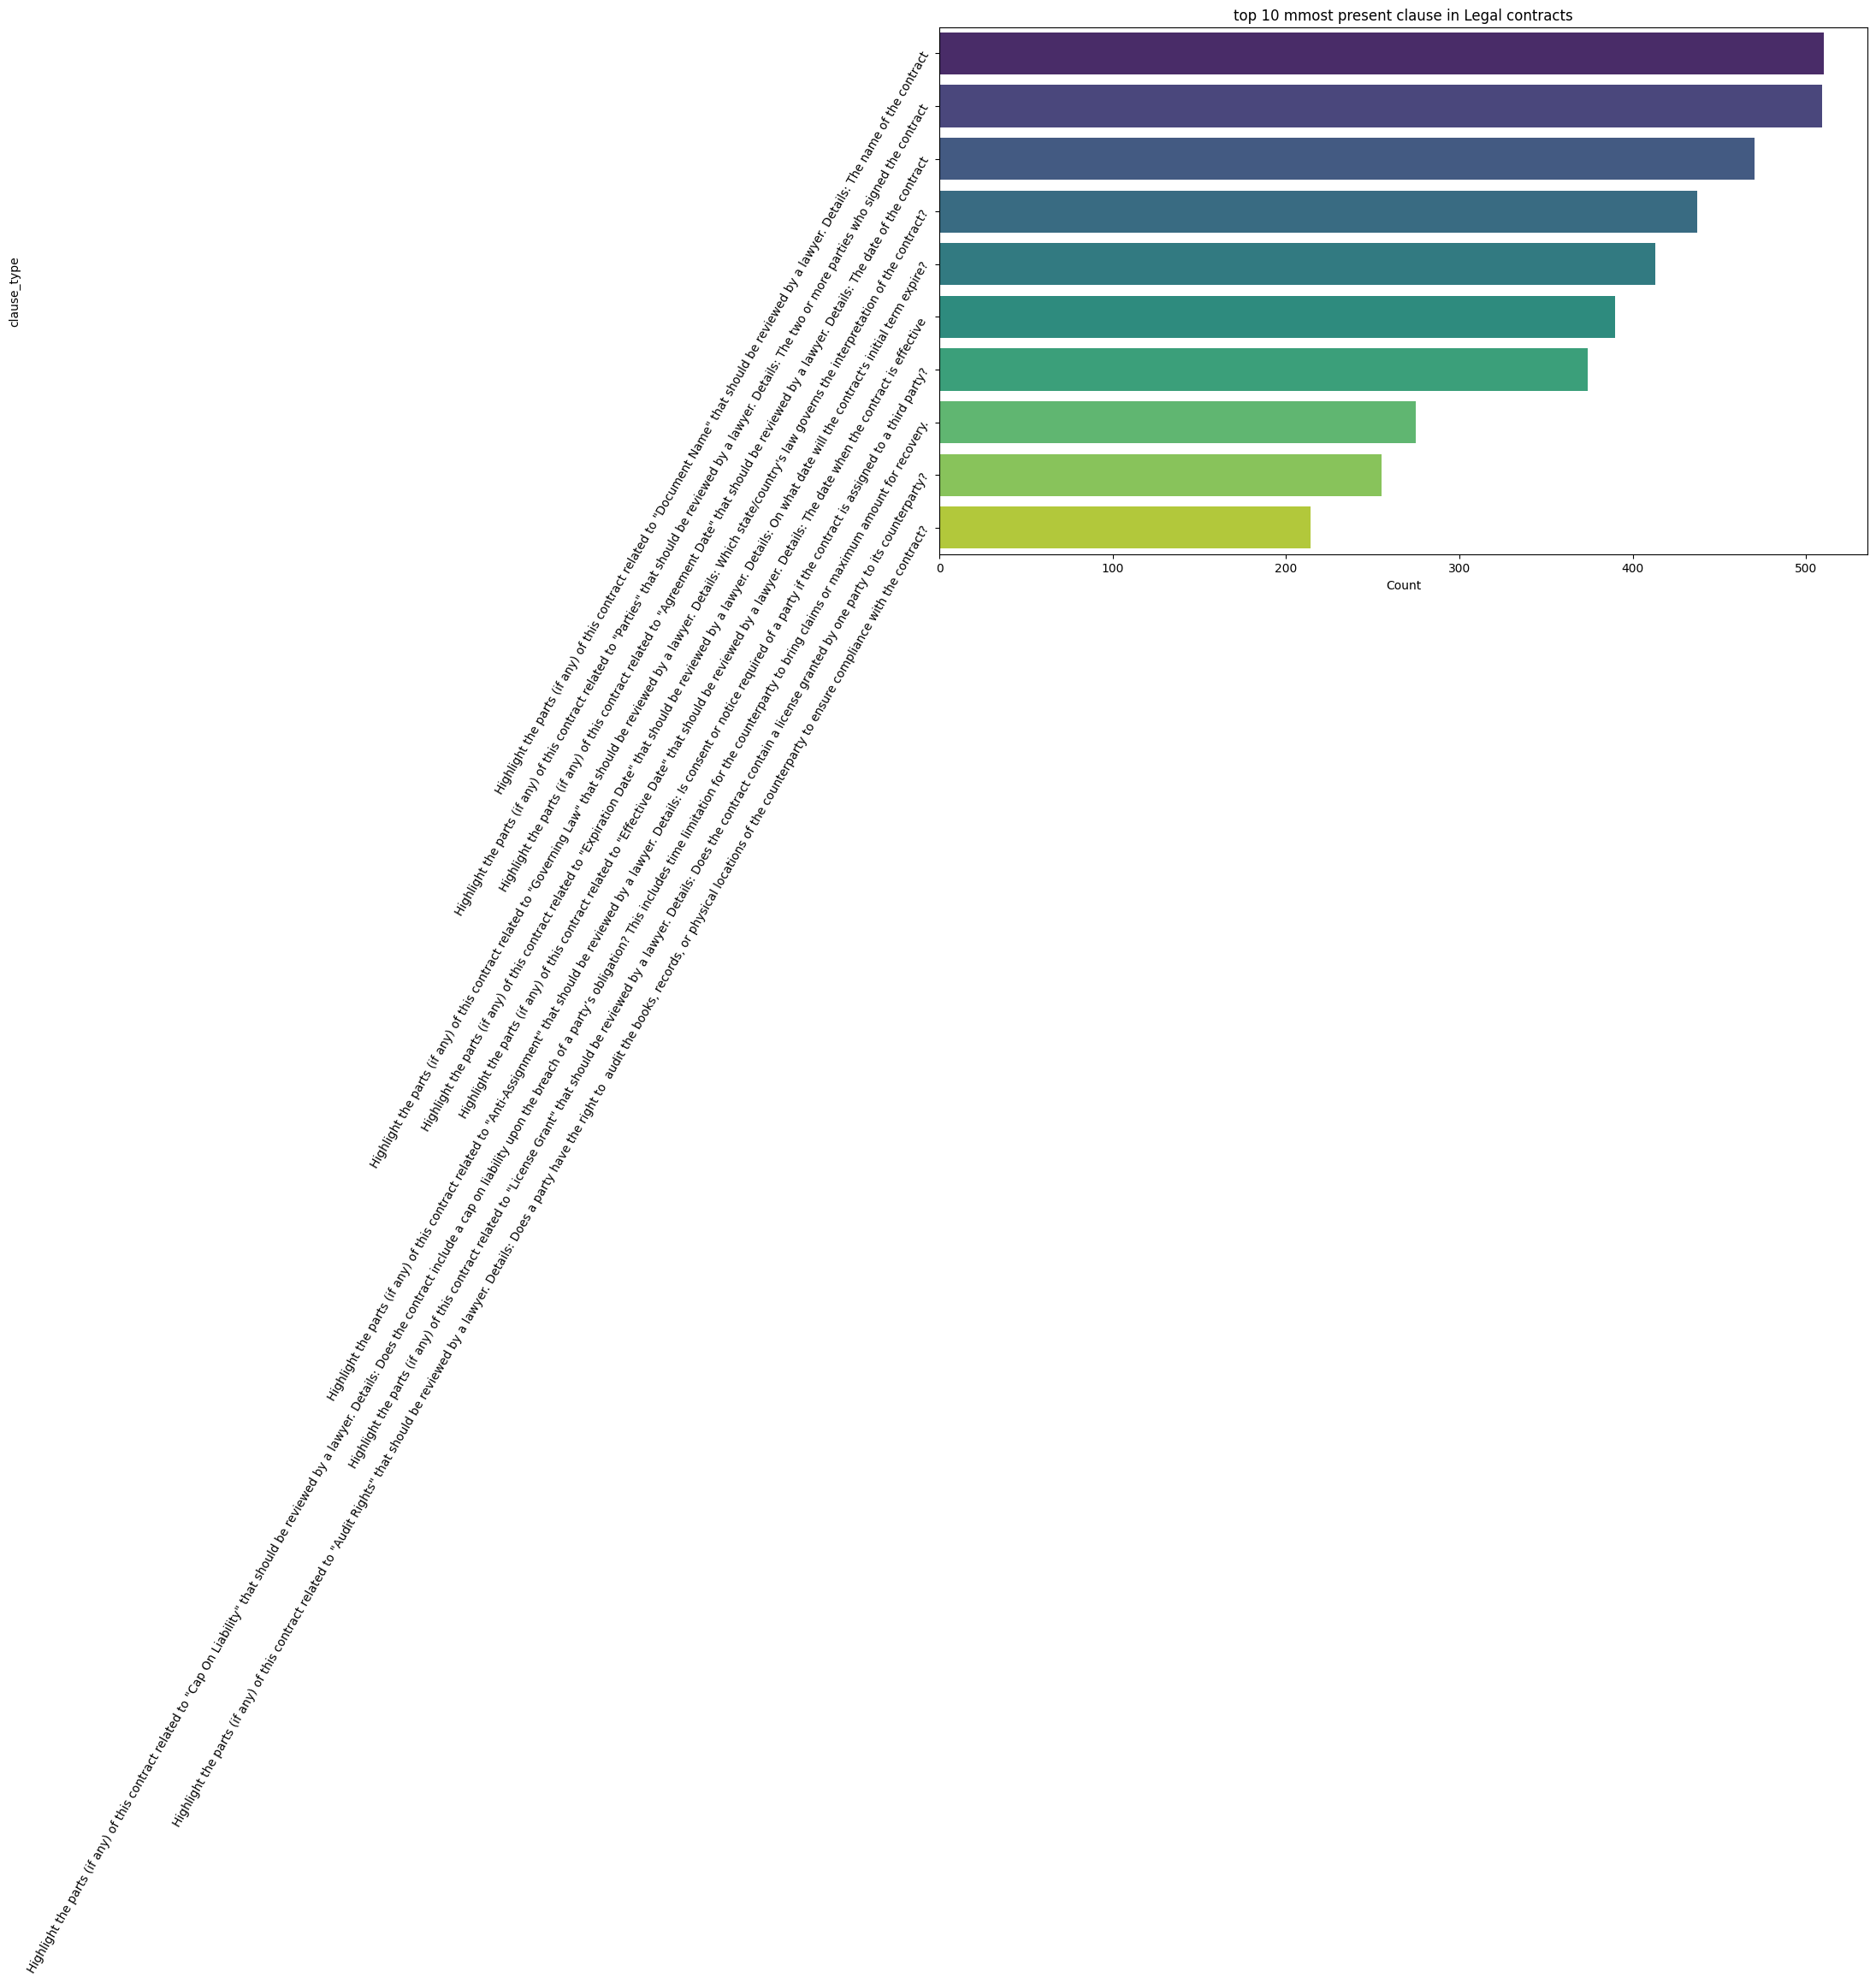

In [10]:
present_clause=df[df['answer'].notnull()]['clause_type'].value_counts().head(10)
plt.figure(figsize=(14,8))
sns.barplot(x=present_clause.values,y=present_clause.index,palette="viridis")
plt.title("top 10 mmost present clause in Legal contracts")
plt.xlabel("Count")
plt.yticks(rotation=60, ha='right')   # or 60
plt.ylabel("clause_type")
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()



C:\Rtemp\ipykernel_9632\1860860099.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_clause.values,y=missing_clause.index,palette="viridis")
C:\Rtemp\ipykernel_9632\1860860099.py:10: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


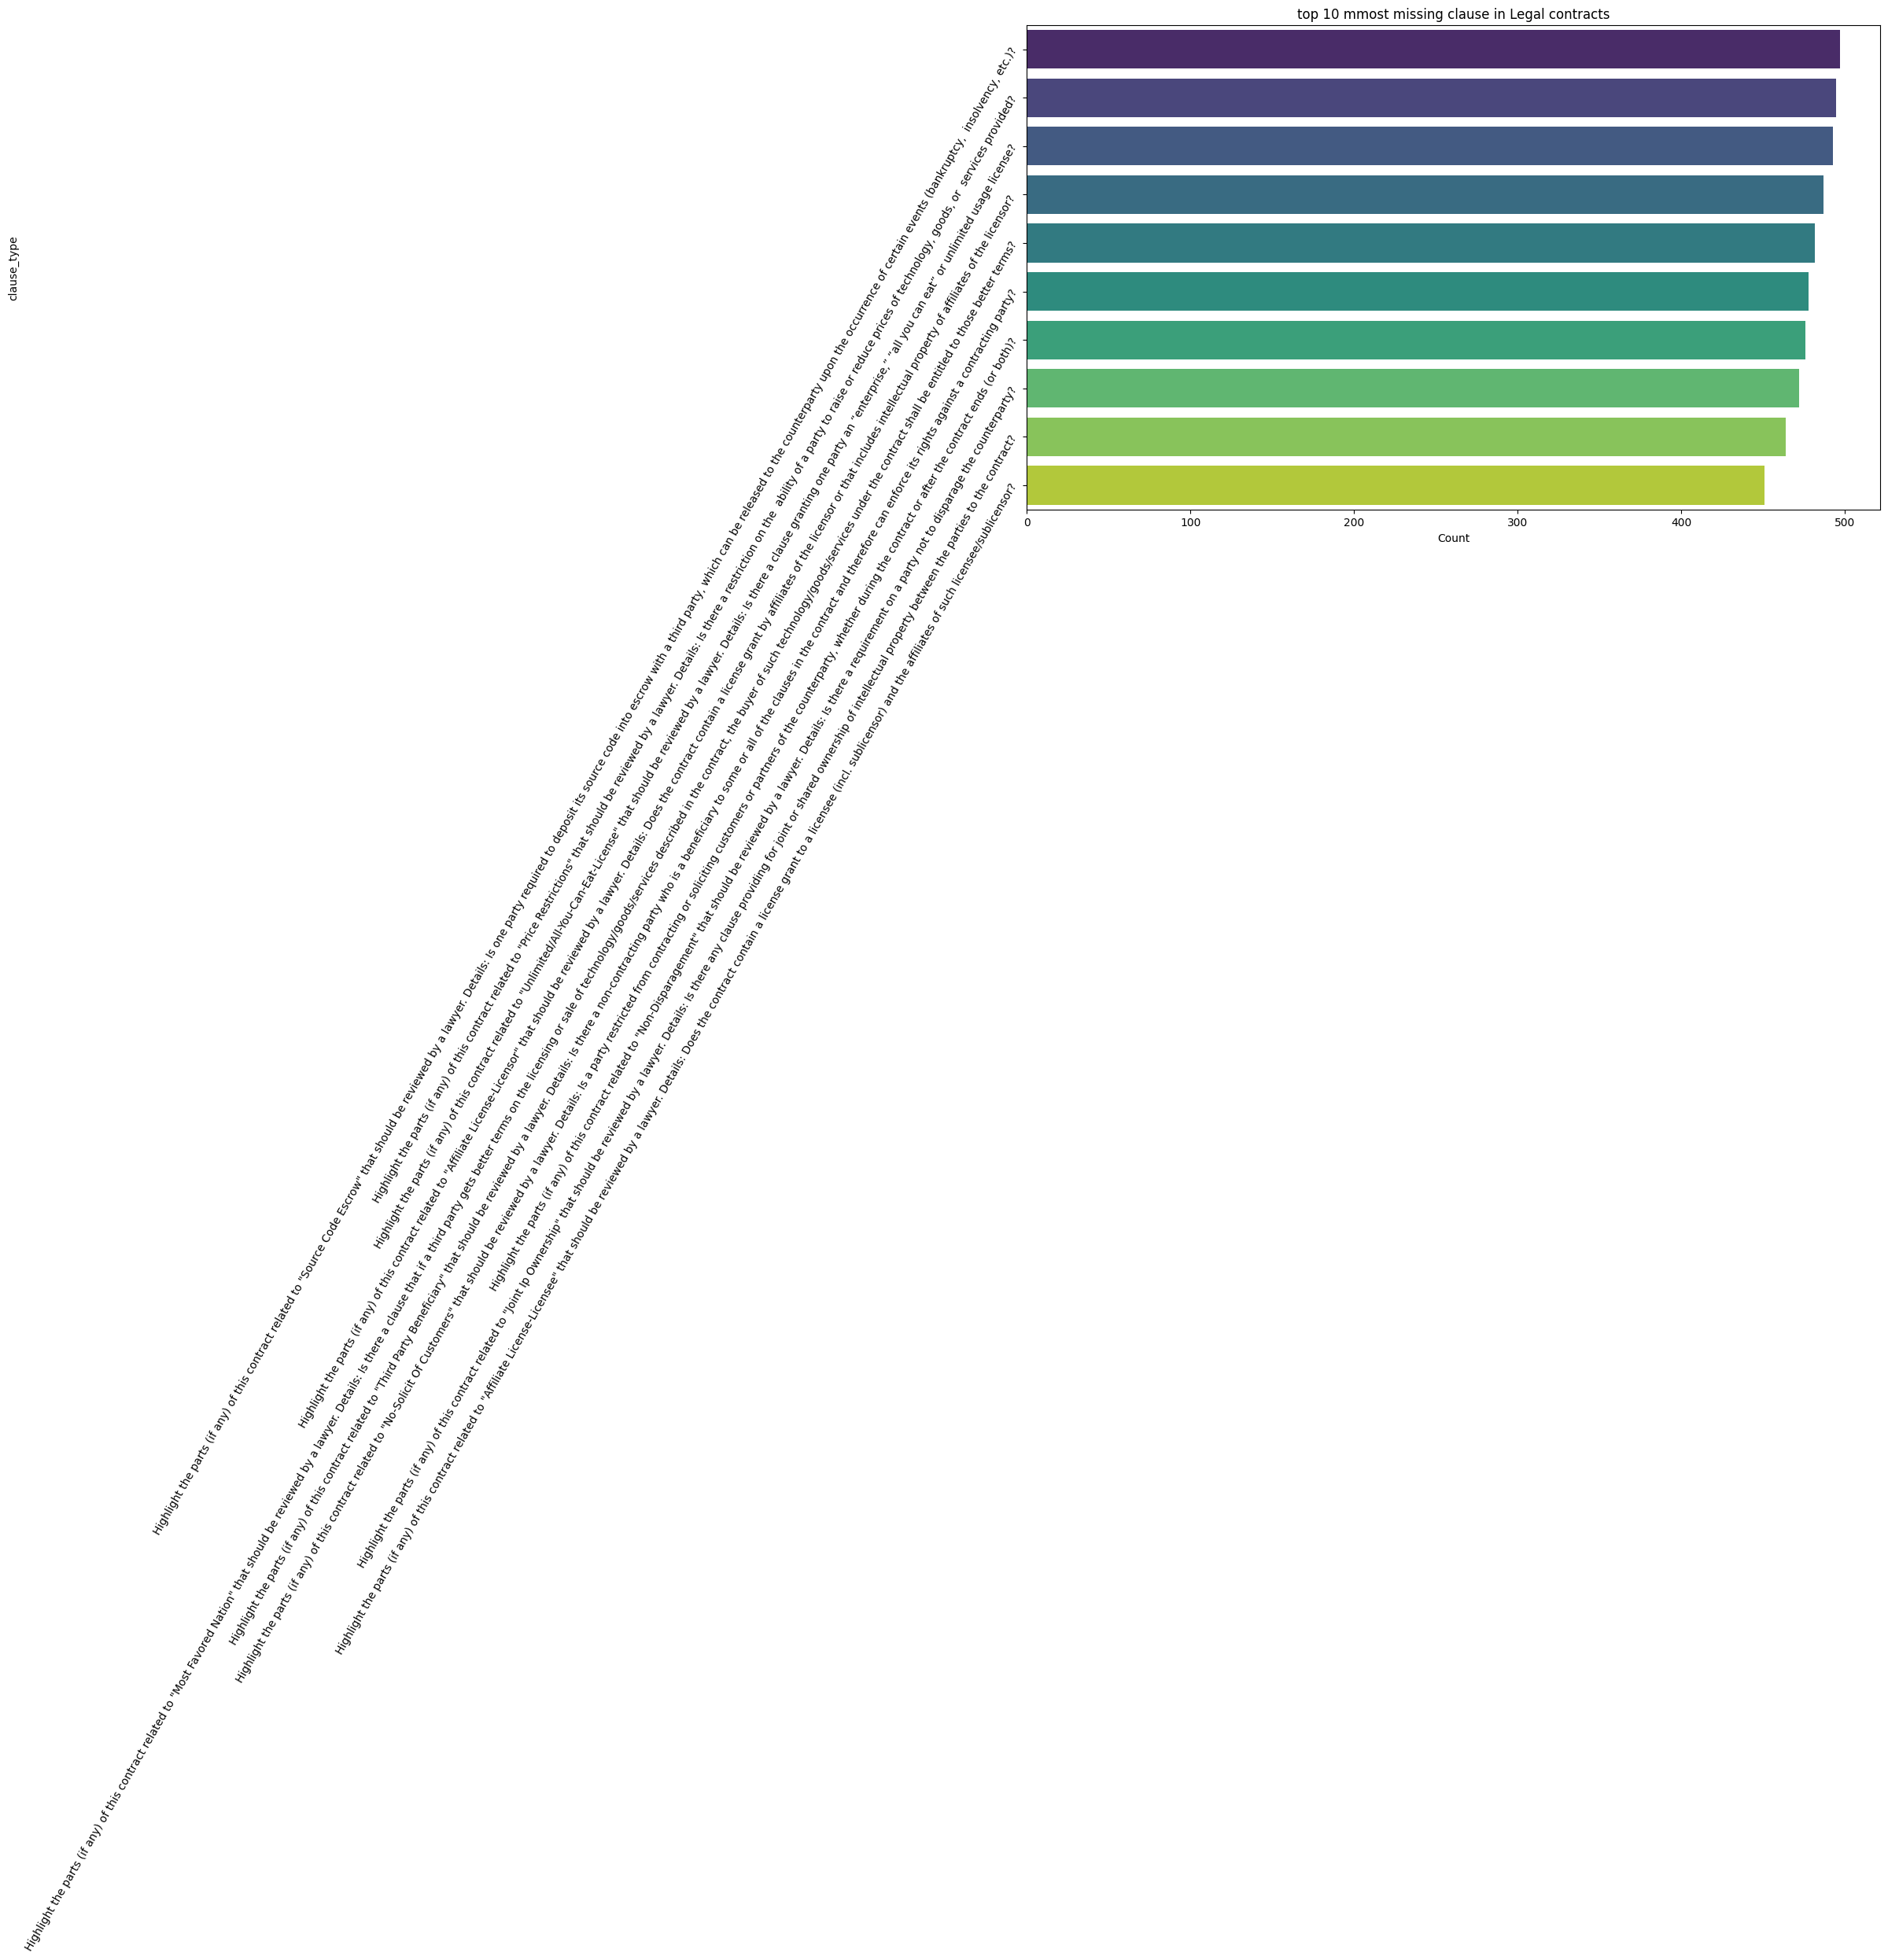

In [11]:
missing_clause=df[df['answer'].isnull()]['clause_type'].value_counts().head(10)
plt.figure(figsize=(14,8))
sns.barplot(x=missing_clause.values,y=missing_clause.index,palette="viridis")
plt.title("top 10 mmost missing clause in Legal contracts")
plt.xlabel("Count")
plt.yticks(rotation=60, ha='right')   # or 60
plt.ylabel("clause_type")
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()


C:\Rtemp\ipykernel_9632\1563121652.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=present_clauses.values, y=present_clauses.index, palette="viridis")


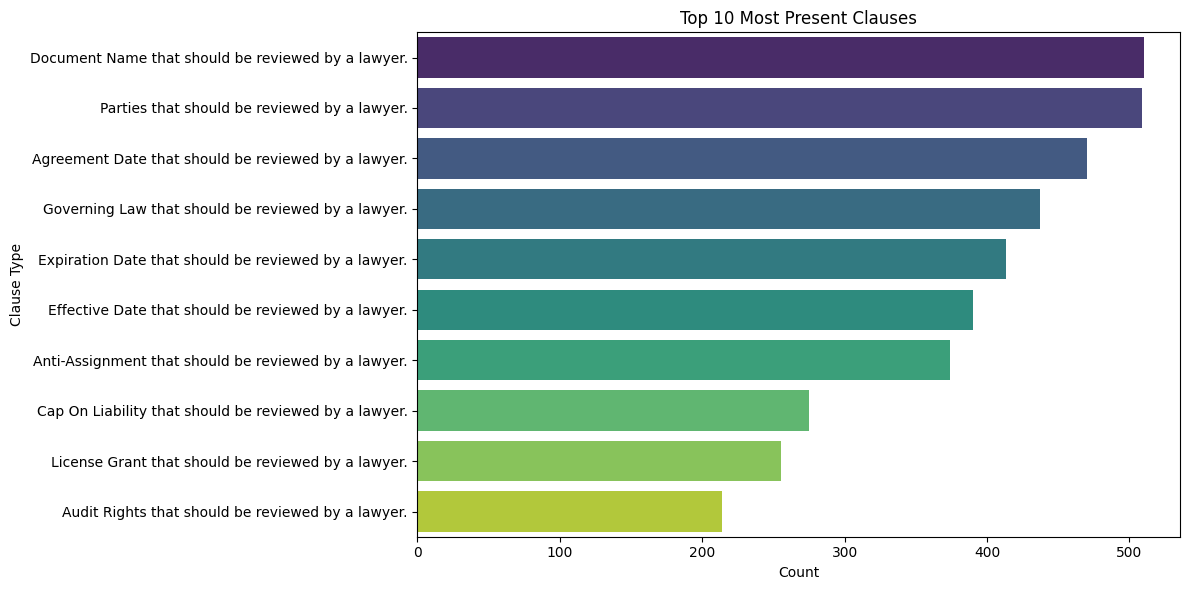

C:\Rtemp\ipykernel_9632\1563121652.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_clauses.values, y=missing_clauses.index, palette="Reds_r")


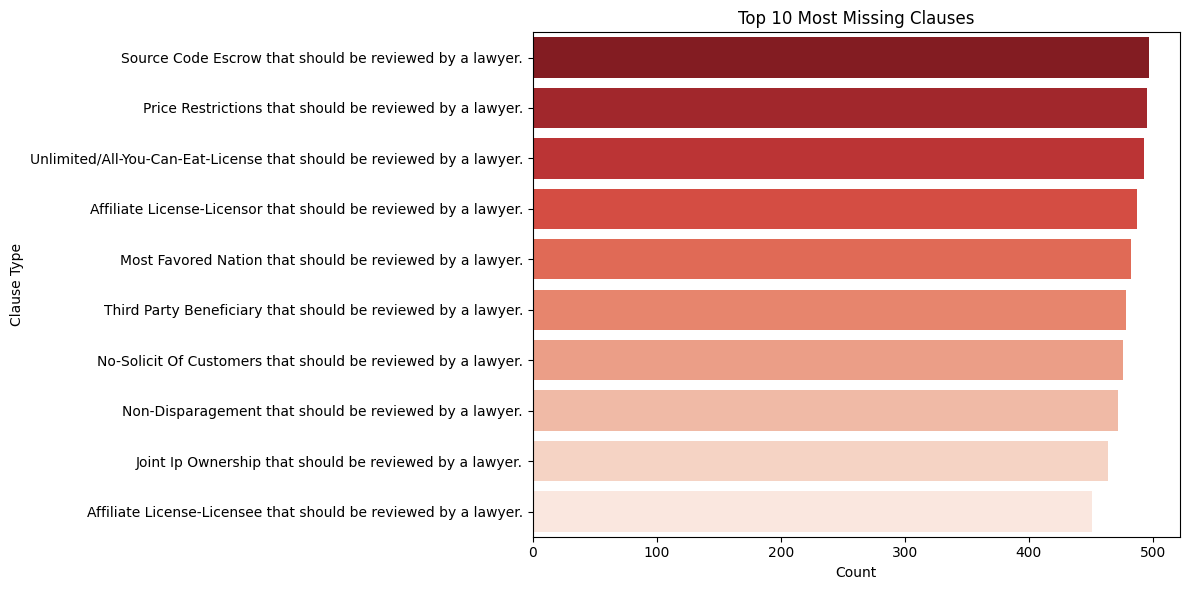

In [12]:
# Clean clause names - remove long descriptions
df['clause_short'] = df['clause_type'].apply(lambda x: x.split('Details:')[0].strip())
df['clause_short'] = df['clause_short'].apply(lambda x: x.replace('Highlight the parts (if any) of this contract related to', '').strip())
df['clause_short'] = df['clause_short'].apply(lambda x: x.replace('"', '').strip())

# Most present clauses
present_clauses = df[df['answer'].notnull()]['clause_short'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=present_clauses.values, y=present_clauses.index, palette="viridis")
plt.title("Top 10 Most Present Clauses")
plt.xlabel("Count")
plt.ylabel("Clause Type")
plt.tight_layout()
plt.show()

# Most missing clauses
missing_clauses = df[df['answer'].isnull()]['clause_short'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=missing_clauses.values, y=missing_clauses.index, palette="Reds_r")
plt.title("Top 10 Most Missing Clauses")
plt.xlabel("Count")
plt.ylabel("Clause Type")
plt.tight_layout()
plt.show()

In [13]:
# Clause presence rate - how often each clause appears
clause_presence = df.groupby('clause_short')['answer'].apply(
    lambda x: x.notnull().sum() / len(x)
).sort_values(ascending=False)

print("Clause Presence Rate (%):")
clause_presence.head(20)

Clause Presence Rate (%):


clause_short
Document Name that should be reviewed by a lawyer.                  1.000000
Parties that should be reviewed by a lawyer.                        0.998039
Agreement Date that should be reviewed by a lawyer.                 0.921569
Governing Law that should be reviewed by a lawyer.                  0.856863
Expiration Date that should be reviewed by a lawyer.                0.809804
Effective Date that should be reviewed by a lawyer.                 0.764706
Anti-Assignment that should be reviewed by a lawyer.                0.733333
Cap On Liability that should be reviewed by a lawyer.               0.539216
License Grant that should be reviewed by a lawyer.                  0.500000
Audit Rights that should be reviewed by a lawyer.                   0.419608
Termination For Convenience that should be reviewed by a lawyer.    0.358824
Post-Termination Services that should be reviewed by a lawyer.      0.356863
Exclusivity that should be reviewed by a lawyer.               

In [14]:
clause_presence.to_csv("clause_weights.csv")

In [19]:

clause_presence.head()

clause_short
Document Name that should be reviewed by a lawyer.      1.000000
Parties that should be reviewed by a lawyer.            0.998039
Agreement Date that should be reviewed by a lawyer.     0.921569
Governing Law that should be reviewed by a lawyer.      0.856863
Expiration Date that should be reviewed by a lawyer.    0.809804
Name: answer, dtype: float64